# 🚗 BoxCars116k → YOLO Dataset

**Objectif** : Convertir BoxCars116k (avec masks) en format YOLOv8

**Dataset** : BoxCars116k - Images véhicules vue du dessus + masks

---

## 📦 Imports

In [1]:
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
import shutil
import matplotlib.pyplot as plt

print('✅ Imports OK')

✅ Imports OK


## 🔧 Configuration

In [3]:
# Paths
BOXCARS_DIR = Path('data/BoxCars116k/images')  # ← Dossier principal images
OUTPUT_DIR = Path('data/boxcars_yolo')

# Créer structure YOLO
for split in ['train', 'val']:
    (OUTPUT_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

print(f'📁 BoxCars source: {BOXCARS_DIR}')
print(f'📁 YOLO output: {OUTPUT_DIR}')

📁 BoxCars source: data/BoxCars116k/images
📁 YOLO output: data/boxcars_yolo


## 🔍 Explorer Dataset BoxCars

In [4]:
# Lister TOUS les fichiers images et masks de manière récursive
image_files = []
mask_files = []

for img_file in BOXCARS_DIR.rglob('*.png'):
    if '_mask' in img_file.name:
        mask_files.append(img_file)
    else:
        image_files.append(img_file)

image_files = sorted(image_files)
mask_files = sorted(mask_files)

print(f'📊 Images trouvées: {len(image_files)}')
print(f'📊 Masks trouvés: {len(mask_files)}')

# Exemples
print(f'\nExemples images:')
for img in image_files[:5]:
    print(f'  {img}')

print(f'\nExemples masks:')
for mask in mask_files[:5]:
    print(f'  {mask}')

📊 Images trouvées: 116286
📊 Masks trouvés: 116286

Exemples images:
  data/BoxCars116k/images/001/0/019700_000.png
  data/BoxCars116k/images/001/0/019700_001.png
  data/BoxCars116k/images/001/0/019700_002.png
  data/BoxCars116k/images/001/0/019700_003.png
  data/BoxCars116k/images/001/0/019700_004.png

Exemples masks:
  data/BoxCars116k/images/001/0/019700_000_mask.png
  data/BoxCars116k/images/001/0/019700_001_mask.png
  data/BoxCars116k/images/001/0/019700_002_mask.png
  data/BoxCars116k/images/001/0/019700_003_mask.png
  data/BoxCars116k/images/001/0/019700_004_mask.png


## 📐 Fonction Mask → BBox

In [5]:
def mask_to_bbox(mask_path):
    """
    Convertit un mask en bounding box YOLO format
    
    Returns:
        [x_center, y_center, width, height] normalisés (0-1)
        ou None si pas de véhicule détecté
    """
    # Lire mask
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None
    
    # Trouver contours du véhicule (pixels blancs)
    coords = np.column_stack(np.where(mask > 0))
    
    if len(coords) == 0:
        return None
    
    # Calculer bounding box
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    
    # Dimensions image
    h, w = mask.shape
    
    # Convertir en format YOLO (centre + dimensions normalisées)
    x_center = ((x_min + x_max) / 2) / w
    y_center = ((y_min + y_max) / 2) / h
    width = (x_max - x_min) / w
    height = (y_max - y_min) / h
    
    return [x_center, y_center, width, height]

# Test
if len(mask_files) > 0:
    test_bbox = mask_to_bbox(mask_files[0])
    print(f'✅ Test bbox: {test_bbox}')

✅ Test bbox: [0.4959677419354839, 0.592, 0.5080645161290323, 0.704]


## 🎨 Visualiser Quelques Exemples

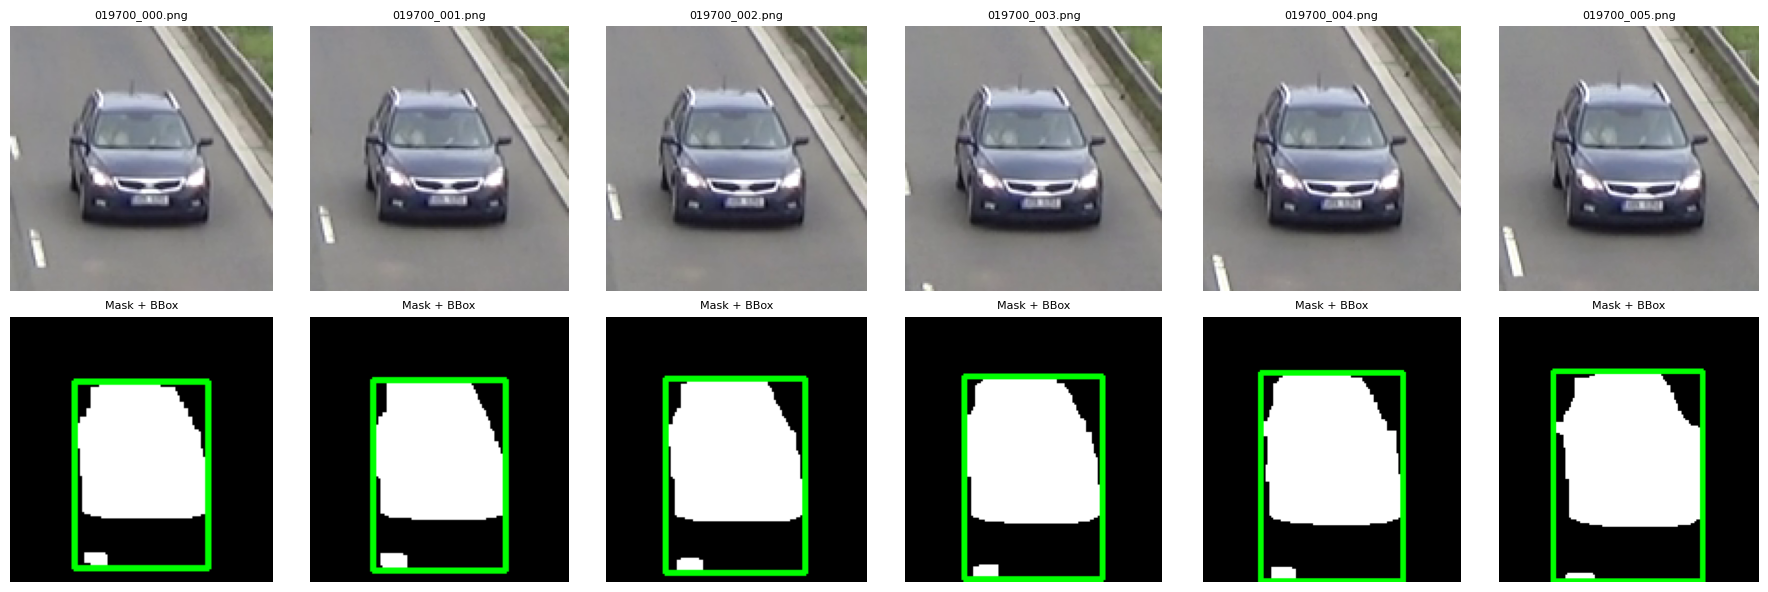

✅ Visualisation OK


In [6]:
# Visualiser 6 exemples
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for idx in range(6):
    if idx >= len(image_files):
        break
    
    img_path = image_files[idx]
    # Trouver mask correspondant
    mask_path = img_path.parent / f"{img_path.stem}_mask.png"
    
    # Lire image et mask
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Image originale
    axes[0, idx].imshow(img_rgb)
    axes[0, idx].set_title(f'{img_path.name}', fontsize=8)
    axes[0, idx].axis('off')
    
    # Mask
    if mask_path.exists():
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        axes[1, idx].imshow(mask, cmap='gray')
        
        # Calculer et afficher bbox
        bbox = mask_to_bbox(mask_path)
        if bbox:
            h, w = img.shape[:2]
            x_c, y_c, bw, bh = bbox
            x1 = int((x_c - bw/2) * w)
            y1 = int((y_c - bh/2) * h)
            x2 = int((x_c + bw/2) * w)
            y2 = int((y_c + bh/2) * h)
            
            # Dessiner bbox sur mask
            mask_viz = cv2.cvtColor(mask, cv2.COLOR_GRAY2RGB)
            cv2.rectangle(mask_viz, (x1, y1), (x2, y2), (0, 255, 0), 2)
            axes[1, idx].imshow(mask_viz)
        
        axes[1, idx].set_title('Mask + BBox', fontsize=8)
    else:
        axes[1, idx].text(0.5, 0.5, 'Pas de mask', ha='center', va='center')
    
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

print('✅ Visualisation OK')

## 🔄 Conversion Complète BoxCars → YOLO

In [7]:
# Split train/val (85/15)
from sklearn.model_selection import train_test_split

train_files, val_files = train_test_split(
    image_files, 
    test_size=0.15, 
    random_state=42
)

print(f'📊 Split:')
print(f'   Train: {len(train_files)} images')
print(f'   Val: {len(val_files)} images')

📊 Split:
   Train: 98843 images
   Val: 17443 images


In [8]:
def convert_to_yolo(image_files, split_name, output_dir):
    """
    Convertit liste d'images BoxCars en format YOLO
    """
    images_dir = output_dir / split_name / 'images'
    labels_dir = output_dir / split_name / 'labels'
    
    converted = 0
    skipped = 0
    
    for img_path in tqdm(image_files, desc=f'Converting {split_name}'):
        # Trouver mask correspondant
        mask_path = img_path.parent / f"{img_path.stem}_mask.png"
        
        if not mask_path.exists():
            skipped += 1
            continue
        
        # Calculer bbox
        bbox = mask_to_bbox(mask_path)
        if bbox is None:
            skipped += 1
            continue
        
        # Copier image
        dest_img = images_dir / img_path.name
        shutil.copy(img_path, dest_img)
        
        # Créer fichier label YOLO
        label_file = labels_dir / f"{img_path.stem}.txt"
        with open(label_file, 'w') as f:
            # Classe 0 = vehicle
            f.write(f"0 {' '.join(map(str, bbox))}\n")
        
        converted += 1
    
    print(f'\n✅ {split_name}:')
    print(f'   Convertis: {converted}')
    print(f'   Ignorés: {skipped}')
    
    return converted

# Conversion
print('🔄 Conversion en cours...\n')
n_train = convert_to_yolo(train_files, 'train', OUTPUT_DIR)
n_val = convert_to_yolo(val_files, 'val', OUTPUT_DIR)

print(f'\n🎉 CONVERSION TERMINÉE!')
print(f'   Total: {n_train + n_val} images converties')

🔄 Conversion en cours...



Converting train: 100%|██████████| 98843/98843 [1:47:36<00:00, 15.31it/s]  



✅ train:
   Convertis: 98843
   Ignorés: 0


Converting val: 100%|██████████| 17443/17443 [17:27<00:00, 16.65it/s] 


✅ val:
   Convertis: 17443
   Ignorés: 0

🎉 CONVERSION TERMINÉE!
   Total: 116286 images converties


## 📄 Créer data.yaml

In [9]:
# Créer fichier config YOLO
yaml_content = f"""# BoxCars116k YOLO Dataset
path: {OUTPUT_DIR.absolute()}
train: train/images
val: val/images

# Classes
nc: 1
names: ['vehicle']
"""

yaml_path = OUTPUT_DIR / 'data.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f'✅ data.yaml créé: {yaml_path}')
print(f'\n📄 Contenu:')
print(yaml_content)

✅ data.yaml créé: data/boxcars_yolo/data.yaml

📄 Contenu:
# BoxCars116k YOLO Dataset
path: /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/data/boxcars_yolo
train: train/images
val: val/images

# Classes
nc: 1
names: ['vehicle']



In [10]:
# Vérifier structure
print('📁 Structure dataset:')
print(f'Train images: {len(list((OUTPUT_DIR / "train" / "images").glob("*.png")))}')
print(f'Train labels: {len(list((OUTPUT_DIR / "train" / "labels").glob("*.txt")))}')
print(f'Val images: {len(list((OUTPUT_DIR / "val" / "images").glob("*.png")))}')
print(f'Val labels: {len(list((OUTPUT_DIR / "val" / "labels").glob("*.txt")))}')

# Vérifier yaml
yaml_path = OUTPUT_DIR / 'data.yaml'
print(f'\n✅ data.yaml existe: {yaml_path.exists()}')

📁 Structure dataset:
Train images: 98843
Train labels: 98843
Val images: 17443
Val labels: 17443

✅ data.yaml existe: True


## ✅ Dataset Prêt!

Vous pouvez maintenant entraîner YOLO avec:
```python
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
model.train(data='data/boxcars_yolo/data.yaml', epochs=30)
```

**Ce dataset sera BEAUCOUP mieux** que Stanford Cars pour vos images réelles !

---

# 🚀 Prochaine Étape : Entraîner YOLO


In [14]:
from ultralytics import YOLO
import torch

print('='*60)
print('🚀 ENTRAÎNEMENT YOLO SUR BOXCARS116K')
print('='*60)

# Vérifier GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n🖥️  Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

# Charger YOLOv8n
print('\n📦 Chargement YOLOv8n...')
model = YOLO('yolov8n.pt')

# Configuration
CONFIG = {
    'data': 'data/boxcars_yolo/data.yaml',
    'epochs': 15,
    'imgsz': 640,
    'batch': 24,
    'patience': 10,
    'device': 0 if torch.cuda.is_available() else 'cpu',
    'workers': 8,
    'amp': True,
    'project': 'models/yolo_boxcars',
    'name': 'vehicle_detector_boxcars',
    'exist_ok': True,
    'pretrained': True,
    'verbose': True,
    'plots': True,
    'save': True,
    'save_period': 5,
}

print(f'\n⚙️  Configuration:')
for key, value in CONFIG.items():
    print(f'   {key}: {value}')

print('\n' + '='*60)
print('🚀 DÉMARRAGE ENTRAÎNEMENT')
print('='*60)
print('Durée estimée: 2-3h avec GPU\n')

# ENTRAÎNEMENT
results = model.train(**CONFIG)

print('\n' + '='*60)
print('🎉 ENTRAÎNEMENT TERMINÉ!')
print('='*60)

## 📊 Ce Qui Va Se Passer

# **Epoch 1-30** :
# - Loss va descendre
# - mAP50 va monter vers **95%+**
# - Sauvegarde toutes les 5 epochs

# **Résultats attendus** :
# - **mAP50** : >0.95 (excellente détection)
# - **mAP50-95** : >0.85
# - **Précision** : >0.95

# ---

# ## 💻 Pendant l'Entraînement

# Vous verrez :
# ```
# Epoch 1/30: 100%|██████| 6125/6125 [12:34<00:00, 8.12it/s]
#       Class  Images  Instances    Box(P    R   mAP50)
#         all   18286      18286    0.892 0.901   0.943

🚀 ENTRAÎNEMENT YOLO SUR BOXCARS116K

🖥️  Device: cuda
   GPU: NVIDIA GeForce RTX 4060 Laptop GPU

📦 Chargement YOLOv8n...

⚙️  Configuration:
   data: data/boxcars_yolo/data.yaml
   epochs: 15
   imgsz: 640
   batch: 24
   patience: 10
   device: 0
   workers: 8
   amp: True
   project: models/yolo_boxcars
   name: vehicle_detector_boxcars
   exist_ok: True
   pretrained: True
   verbose: True
   plots: True
   save: True
   save_period: 5

🚀 DÉMARRAGE ENTRAÎNEMENT
Durée estimée: 2-3h avec GPU

New https://pypi.org/project/ultralytics/8.4.14 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.12 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=24, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/box

In [15]:
# Chercher le modèle sauvegardé
from pathlib import Path

# Chemins possibles
possible_paths = [
    Path('models/yolo_boxcars/vehicle_detector_boxcars/weights/best.pt'),
    Path('runs/detect/train/weights/best.pt'),
    Path('runs/detect/vehicle_detector_boxcars/weights/best.pt'),
]

print('🔍 Recherche du modèle best.pt...\n')

for path in possible_paths:
    if path.exists():
        print(f'✅ TROUVÉ: {path}')
        print(f'   Taille: {path.stat().st_size / 1024 / 1024:.2f} MB')
    else:
        print(f'❌ Pas trouvé: {path}')

# Recherche globale
print('\n📂 Recherche globale de tous les best.pt:')
for pt_file in Path('.').rglob('best.pt'):
    print(f'✅ {pt_file}')
    print(f'   Taille: {pt_file.stat().st_size / 1024 / 1024:.2f} MB')

🔍 Recherche du modèle best.pt...

❌ Pas trouvé: models/yolo_boxcars/vehicle_detector_boxcars/weights/best.pt
❌ Pas trouvé: runs/detect/train/weights/best.pt
❌ Pas trouvé: runs/detect/vehicle_detector_boxcars/weights/best.pt

📂 Recherche globale de tous les best.pt:
✅ runs/detect/models/yolo_boxcars/vehicle_detector_boxcars/weights/best.pt
   Taille: 5.93 MB
✅ runs/detect/models/yolo_vehicle_detector/vehicle_detector/weights/best.pt
   Taille: 5.96 MB


In [16]:
from ultralytics import YOLO

# Charger le meilleur modèle BoxCars
best_model_path = 'runs/detect/models/yolo_boxcars/vehicle_detector_boxcars/weights/best.pt'
model = YOLO(best_model_path)

# Valider
metrics = model.val()

print('📊 MÉTRIQUES YOLO BOXCARS:')
print(f'mAP50: {metrics.box.map50:.4f}')
print(f'mAP50-95: {metrics.box.map:.4f}')
print(f'Precision: {metrics.box.mp:.4f}')
print(f'Recall: {metrics.box.mr:.4f}')

Ultralytics 8.4.12 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 1.8±0.2 ms, read: 13.8±2.8 MB/s, size: 44.0 KB)
val: Scanning /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/data/boxcars_yolo/val/labels.cache... 17443 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 17443/17443 114.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1091/1091 8.3it/s 2:12<0.1s
                   all      17443      17443      0.987      0.991      0.993      0.962
Speed: 0.8ms preprocess, 1.9ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/DETECT_MODE_CARS/runs/detect/val3
📊 MÉTRIQUES YOLO BOXCARS:
mAP50: 0.9930
mAP50-95: 0.9621
Precision: 0.9873
Recall: 0


image 1/1 /mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_YOLO8-n_&_OCR/ROBOFLOW_universe/License-Plate-Recognition-4/train/images/00d087736d290d66_jpg.rf.56f9e2cb4f82e57ef671d1b753dd05fa.jpg: 640x640 1 vehicle, 31.3ms
Speed: 3.8ms preprocess, 31.3ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)


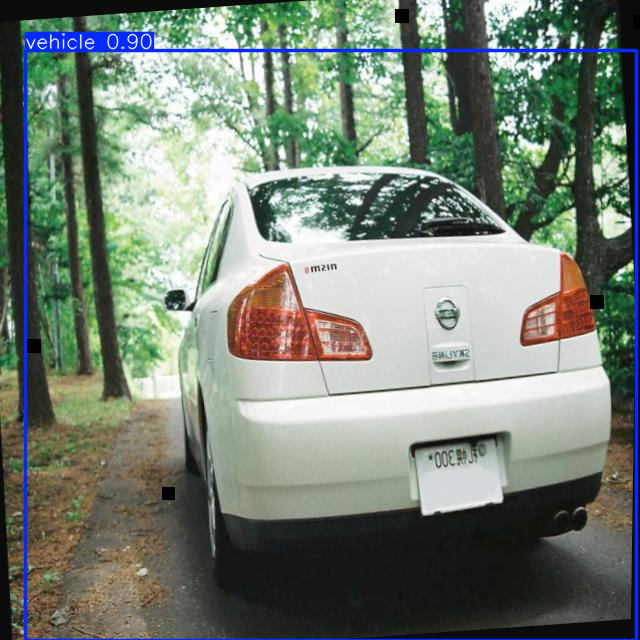

In [23]:
# Test sur image
test_image = '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_YOLO8-n_&_OCR/ROBOFLOW_universe/License-Plate-Recognition-4/train/images/00d087736d290d66_jpg.rf.56f9e2cb4f82e57ef671d1b753dd05fa.jpg'
results = model(test_image, conf=0.25)

# Afficher
results[0].show()

In [24]:
def predict_pipeline_boxcars(image_path, yolo_model, classifier, vehicle_classes, device):
    """
    Pipeline avec RÉDUCTION bbox pour compenser détections larges
    """
    # Charger image
    image = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    
    # Détection YOLO
    yolo_results = yolo_model(image, conf=0.25, verbose=False)
    
    if len(yolo_results[0].boxes) == 0:
        return None, image_rgb, "Aucun véhicule"
    
    # Prendre bbox
    box = yolo_results[0].boxes[0]
    x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
    
    # RÉDUIRE bbox de 20% (car BoxCars détecte trop large)
    bbox_w = x2 - x1
    bbox_h = y2 - y1
    margin_w = int(bbox_w * 0.15)  # Réduire 15%
    margin_h = int(bbox_h * 0.15)
    
    x1_reduced = min(w, x1 + margin_w)
    y1_reduced = min(h, y1 + margin_h)
    x2_reduced = max(0, x2 - margin_w)
    y2_reduced = max(0, y2 - margin_h)
    
    # Crop véhicule
    vehicle_crop = image_rgb[y1_reduced:y2_reduced, x1_reduced:x2_reduced]
    
    # Classification
    transform = get_transforms(img_size=224, is_train=False)
    transformed = transform(image=vehicle_crop)['image'].unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = classifier(transformed)
        probs = torch.softmax(outputs, dim=1)
        top_k_probs, top_k_idx = torch.topk(probs, 3)
    
    top_3_classes = [vehicle_classes[idx.item()] for idx in top_k_idx[0]]
    top_3_probs = top_k_probs[0].cpu().numpy()
    
    return {
        'bbox_original': [x1, y1, x2, y2],
        'bbox_reduced': [x1_reduced, y1_reduced, x2_reduced, y2_reduced],
        'yolo_conf': float(box.conf[0]),
        'top_3_classes': top_3_classes,
        'top_3_probs': top_3_probs,
        'vehicle_crop': vehicle_crop
    }, image_rgb, None